# Data Challenge Example Notebook

You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import torch_directml

ModuleNotFoundError: No module named 'sklearn'

### Load dataframes

In [3]:
df_train = pd.read_csv("../occlusion_datasets/train.csv", delimiter=',')
df_test = pd.read_csv("../occlusion_datasets/test_students.csv", delimiter=',')

image_dir = "../crops/Crop_224_5fp_100K"

In [4]:
df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [5]:
df_test.head()

,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [4]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [5]:
df_val = df_train.loc[:20000].reset_index()
df_train = df_train.loc[20000:].reset_index()

In [9]:
len(df_train), len(df_val), len(df_test)

(80000, 20001, 29980)

### Check that all images are read correctly

In [10]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)
        
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

100%|██████████| 29980/29980 [00:07<00:00, 4133.73it/s]


### Display random images

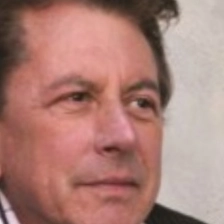

database3/database3/m.01kv3z4/29-FaceId-0_align.webp 0.04606 1.0


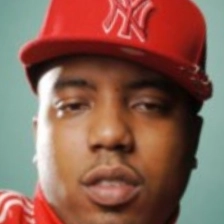

database3/database3/m.025sx_p/19-FaceId-0_align.webp 0.19519 1.0


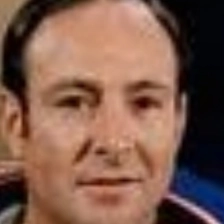

database3/database3/m.01s69k/55-FaceId-0_align.webp 0.013553 1.0


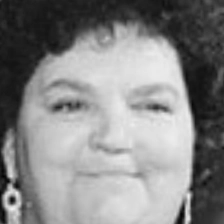

database3/database3/m.01nff17/31-FaceId-0_align.webp 0.109572 0.0


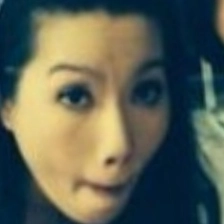

database3/database3/m.025zvd0/120-FaceId-0_align.webp 0.131359 0.0


In [11]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [ ]:
class Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, df, image_dir, training=True):
         'Initialization'
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transforms.ToTensor()
         
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.df)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        row = self.df.loc[index]
        filename = row['filename']

        # Load data and get label
        img = Image.open(f"{image_dir}/{filename}")

        X = self.transform(img)

        if self.training:
            y = row['FaceOcclusion']
            y = np.float32(y)
            gender = row['gender']
            return X, y, gender, filename
        else:
            y = None
            gender = None
            return X, filename

In [7]:
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)
test_set = Dataset(df_test, image_dir, training=False)

params_train = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 4}

params_val = {'batch_size': 64,
          'shuffle': False,
          'num_workers': 4}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

### Create naive model

In [13]:
from torchvision.models import mobilenet_v3_small
model = torchvision.models.mobilenet_v3_small(num_classes=1)
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

#### Count number of parameters

In [9]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_trainable_params = 0
    total_params = 0
    for name, parameter in model.named_parameters():
        params = parameter.numel()
        total_params += params
        if not parameter.requires_grad:
            continue
        table.add_row([name, params])
        total_trainable_params += params
    print(table)
    print(f"Total Trainable Params: {total_trainable_params}")
    print(f"Total Params: {total_params}")
    
count_parameters(model)

+--------------------------------+------------+
|            Modules             | Parameters |
+--------------------------------+------------+
|      features.0.0.weight       |    432     |
|      features.0.1.weight       |     16     |
|       features.0.1.bias        |     16     |
|  features.1.block.0.0.weight   |    144     |
|  features.1.block.0.1.weight   |     16     |
|   features.1.block.0.1.bias    |     16     |
| features.1.block.1.fc1.weight  |    128     |
|  features.1.block.1.fc1.bias   |     8      |
| features.1.block.1.fc2.weight  |    128     |
|  features.1.block.1.fc2.bias   |     16     |
|  features.1.block.2.0.weight   |    256     |
|  features.1.block.2.1.weight   |     16     |
|   features.1.block.2.1.bias    |     16     |
|  features.2.block.0.0.weight   |    1152    |
|  features.2.block.0.1.weight   |     72     |
|   features.2.block.0.1.bias    |     72     |
|  features.2.block.1.0.weight   |    648     |
|  features.2.block.1.1.weight   |     7

### Loss and optimizer

In [10]:
loss_fn = nn.MSELoss()

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train naive model

In [14]:
import torch_directml
device = torch_directml.device()
print(f"Device utilisé : {device}")
print(f"Nom du GPU : {torch_directml.device_name(0)}")

Device utilisé : privateuseone:0
Nom du GPU : Intel(R) Arc(TM) 140V GPU (16GB) 


In [15]:
model = model.to(device)
# use_cuda = torch.cuda.is_available()
# device = torch.device("cuda:0" if use_cuda else "cpu")
# torch.backends.cudnn.benchmark = True
# vgg16_features = vgg16(weights='IMAGENET1K_V1').features.to(device)

#### Fit on train split

In [ ]:
from tqdm.auto import tqdm 

num_epochs = 1

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    seen_samples = 0
    pbar = tqdm(training_generator, total=len(training_generator), desc=f"Epoch {epoch + 1}/{num_epochs}", leave=True)

    for batch_idx, (X, y, gender, filename) in enumerate(pbar, start=1):
        X, y = X.to(device), y.to(device)
        y = y.view(-1, 1)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        if torch.isnan(loss):
            print("NaN detected in batch")
            print(filename)
            print('label', y)
            print('y_pred', y_pred)
            break

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = X.size(0)
        seen_samples += batch_size
        running_loss += loss.item() * batch_size
        mean_loss = running_loss / max(seen_samples, 1)
        pbar.set_postfix(loss=f"{loss.item():.4f}", mean_loss=f"{mean_loss:.4f}", batch=batch_idx)

    print(f"Epoch {epoch + 1}/{num_epochs} - mean loss: {running_loss / max(seen_samples, 1):.4f}")

c:\Users\remi1\projets_ms_ia\datachallenge704\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch 1/1:   0%|          | 0/1250 [00:00<?, ?it/s]

## Evaluate metric on validation split

In [ ]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [ ]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        for i in range(len(X)):

            results_list.append({'filename': filename[i],
                                 'pred': float(y_pred[i]),
                                  'target': float(y[i]),
                                  'gender': float(gender[i])
                                 })
results_df = pd.DataFrame(results_list)

100%|█████████████████████████████████████████| 313/313 [01:20<00:00,  3.90it/s]


In [ ]:
results_df.head()

,filename,pred,target,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.013374,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.033009,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.018109,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.146553,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.266857,0.252091,1.0


<Axes: >

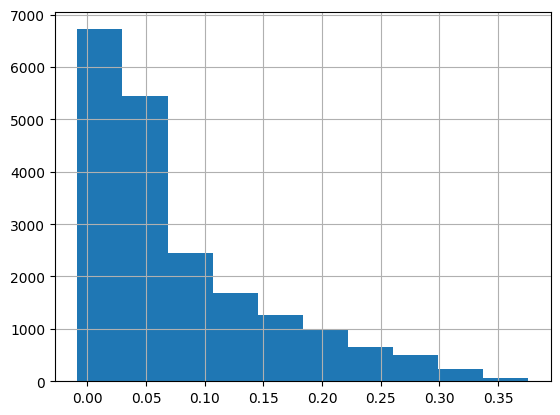

In [ ]:
import matplotlib.pyplot as plt
results_df['pred'].hist()


In [ ]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [ ]:
metric_fn(results_male, results_female)

np.float64(0.00428758396351392)

### Make predictions on test dataset

In [ ]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, filename) in tqdm(enumerate(test_generator), total=len(test_generator)):
        X = X.to(device)
        y_pred = model(X)
    
        for i in range(len(X)):
            results_list.append({'filename': filename[i],
                                 'FaceOcclusion': float(y_pred[i]),
                                 })
results_df = pd.DataFrame(results_list)

100%|█████████████████████████████████████████| 469/469 [01:50<00:00,  4.25it/s]


In [ ]:
results_df.head()

,filename,FaceOcclusion
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.134231
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.090508
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.060727
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.100883
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.107763


### Export predictions
Note: We need to add a dummy 'gender' column for the hfactory upload.

In [ ]:
results_df['gender'] = 'x'
results_df.to_csv("test_predictions.csv", sep=',', index=False)